In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time

# jacobi errors
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, k + 1, errors
        x = x_new
    return x, max_iterations, errors

# gauss_seidel errors
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, k + 1, errors
        x = x_new
    return x, max_iterations, errors


def run_system(A, b):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x0 = np.zeros(3)

    max_iterations = 10000

    for tol in [1e-3, 1e-6, 1e-9]:
        print(f"\nTolerance = {tol}")

        # Jacobi
        start = time.perf_counter()
        x_jac, iter_jac, err_jac = jacobi(A, b, x0, tol, max_iterations)
        time_jac = time.perf_counter() - start

        # Gauss-Seidel
        start = time.perf_counter()
        x_gs, iter_gs, err_gs = gauss_seidel(A, b, x0, tol, max_iterations)
        time_gs = time.perf_counter() - start

        print("\nJacobi:")
        print("  Iterations:", iter_jac)
        print("  Time:", round(time_jac, 6), "seconds")

        print("Gauss-Seidel:")
        print("  Iterations:", iter_gs)
        print("  Time:", round(time_gs, 6), "seconds")

        # Plot convergence (used log so you can actually see a difference I searched this up)
        plt.figure()
        plt.plot(np.log10(err_jac), label="Jacobi")
        plt.plot(np.log10(err_gs), label="Gauss-Seidel")
        plt.xlabel("Iteration")
        plt.ylabel("log10(Absolute Error)")
        plt.legend()
        plt.grid()
        plt.show()

# Discussion
# As the tolerance gets smaller and smaller, both methods need more iterations to 
# find the result because the result has to be more and more precise. Through this
# code and timing everything, I found that the Gauss-Seidel method is faster than 
# the Jacobi method because it changes the variable immediately instead of waiting 
# for the next next like the Jacobi does.|


Tolerance = 0.001

Jacobi:
  Iterations: 4
  Time: 0.000284 seconds
Gauss-Seidel:
  Iterations: 4
  Time: 0.000158 seconds


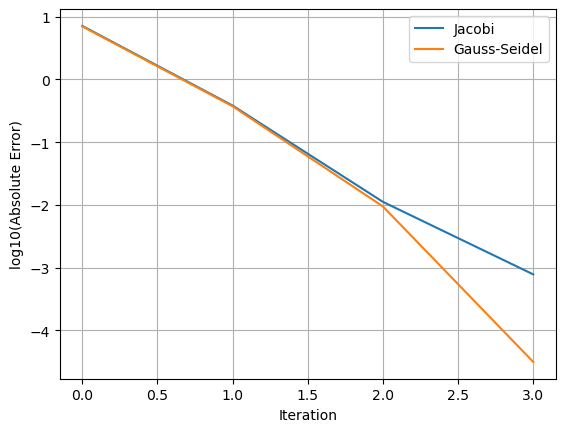


Tolerance = 1e-06

Jacobi:
  Iterations: 7
  Time: 0.000242 seconds
Gauss-Seidel:
  Iterations: 5
  Time: 9.2e-05 seconds


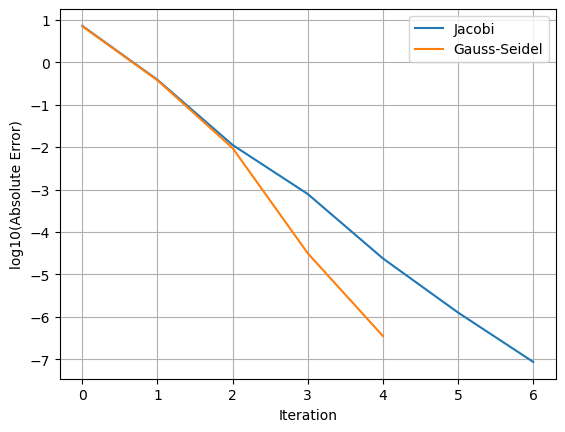


Tolerance = 1e-09

Jacobi:
  Iterations: 9
  Time: 0.0003 seconds
Gauss-Seidel:
  Iterations: 7
  Time: 0.000122 seconds


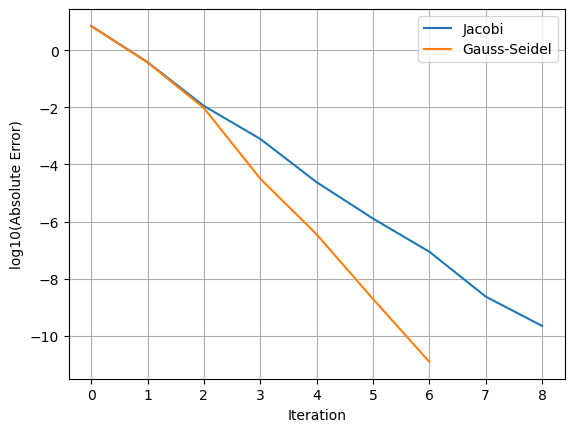

In [24]:
A = [
    [3,   -0.1, -0.2],
    [0.1,  7,   -0.3],
    [0.3, -0.2,  10]
]

b = [7.85, -19.3, 71.4]

run_system(A, b)